In [34]:
import re
import os
import ast
import gzip
import pandas as pd
from Bio import SeqIO
from Bio import SwissProt
import matplotlib.pyplot as plt

In [15]:
path = '../data/uniprot_sprot.fasta.gz'
data = []

with gzip.open(path, 'rt') as handle:
    for record in SeqIO.parse(handle, 'fasta'):

        desc = record.description

        os_match = re.search(r"OS=(.*?) OX=", desc)
        organism = os_match.group(1) if os_match else None

        ox_match = re.search(r"OX=(\d+)", desc)
        taxonomy = int(ox_match.group(1)) if ox_match else None

        gn_match = re.search(r"GN=([^ ]+)", desc)
        gene_name = gn_match.group(1) if gn_match else None

        pe_match = re.search(r"PE=(\d)", desc)
        pe_level = int(pe_match.group(1)) if pe_match else None

        data.append({
            'id': record.id.split('|')[1],  
            'entry_name': record.id.split('|')[2],
            'organism': organism,
            'taxonomy': taxonomy,
            'gene_name': gene_name,
            'pe_level': pe_level,
            'sequence': str(record.seq),
            'length': len(record.seq),
            'description': desc
        })

df_fasta = pd.DataFrame(data)

In [16]:
df_fasta

,id,entry_name,organism,taxonomy,gene_name,pe_level,sequence,length,description
0,Q6GZX4,001R_FRG3G,Frog virus 3 (isolate Goorha),654924,FV3-001R,4,MAFSAEDVLKEYDRRRRMEALLLSLYYPNDRKLLDYKEWSPPRVQV...,256,sp|Q6GZX4|001R_FRG3G Putative transcription fa...
1,Q6GZX3,002L_FRG3G,Frog virus 3 (isolate Goorha),654924,FV3-002L,4,MSIIGATRLQNDKSDTYSAGPCYAGGCSAFTPRGTCGKDWDLGEQT...,320,sp|Q6GZX3|002L_FRG3G Uncharacterized protein 0...
2,Q197F8,002R_IIV3,Invertebrate iridescent virus 3,345201,IIV3-002R,4,MASNTVSAQGGSNRPVRDFSNIQDVAQFLLFDPIWNEQPGSIVPWK...,458,sp|Q197F8|002R_IIV3 Uncharacterized protein 00...
3,Q197F7,003L_IIV3,Invertebrate iridescent virus 3,345201,IIV3-003L,4,MYQAINPCPQSWYGSPQLEREIVCKMSGAPHYPNYYPVHPNALGGA...,156,sp|Q197F7|003L_IIV3 Uncharacterized protein 00...
4,Q6GZX2,003R_FRG3G,Frog virus 3 (isolate Goorha),654924,FV3-003R,3,MARPLLGKTSSVRRRLESLSACSIFFFLRKFCQKMASLVFLNSPVY...,438,sp|Q6GZX2|003R_FRG3G Uncharacterized protein 3...
...,...,...,...,...,...,...,...,...,...
574622,Q6UY62,Z_SABVB,Sabia mammarenavirus (isolate Human/Brasil/SPH...,3052299,Z,1,MGNSKSKSKLSANQYEQQTVNSTKQVAILKRQAEPSLYGRHNCRCC...,100,sp|Q6UY62|Z_SABVB RING finger protein Z OS=Sab...
574623,P08105,Z_SHEEP,Ovis aries,9940,None,4,MSSSLEITSFYSFIWTPHIGPLLFGIGLWFSMFKEPSHFCPCQHPH...,79,sp|P08105|Z_SHEEP Putative uncharacterized pro...
574624,Q88470,Z_TACVF,Tacaribe virus (strain Franze-Fernandez),928313,Z,1,MGNCNRTQKPSSSSNNLEKPPQAAEFRRTAEPSLYGRYNCKCCWFA...,95,sp|Q88470|Z_TACVF RING finger protein Z OS=Tac...
574625,A9JR22,Z_TAMVU,Tamiami mammarenavirus (isolate Rat/United Sta...,3052329,Z,3,MGLRYSKEVRDRHGDKDPEGRIPITQTMPQTLYGRYNCKSCWFANK...,95,sp|A9JR22|Z_TAMVU RING finger protein Z OS=Tam...


In [17]:
# Total sequences parsed
total_sequences = len(df_fasta)
print(f"Total sequences parsed: {total_sequences}")

Total sequences parsed: 574627


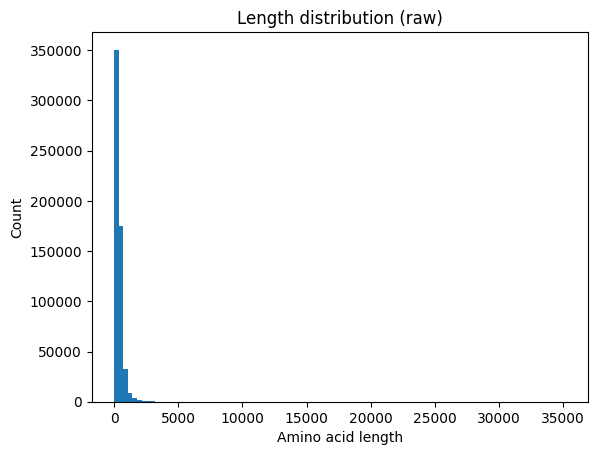

In [18]:
# Length distribution before filtering
plt.figure()
plt.hist(df_fasta['length'], bins=100)
plt.title('Length distribution (raw)')
plt.xlabel('Amino acid length')
plt.ylabel('Count')
plt.show()

In [23]:
fragment_count = df_fasta["description"].str.contains("Fragment", na=False).sum()
print("Sequences with fragments:", fragment_count)

Sequences with fragments: 9266


In [24]:
# Filtering
df_fasta_filtered = df_fasta[~df_fasta['description'].str.contains('Fragment', na=False)]
print(f"Total sequences parsed after removing fragments: {len(df_fasta_filtered)}")

Total sequences parsed after removing fragments: 565361


In [25]:
long_count = (df_fasta_filtered["length"] > 1024).sum()
print("Sequences >1024 aa:", long_count)

Sequences >1024 aa: 18156


In [26]:
# length cap at 1024 amino acids
final_fasta_df = df_fasta_filtered[df_fasta_filtered['length'] <= 1024]
print(f"Total sequences parsed after cap: {len(final_fasta_df)}")

Total sequences parsed after cap: 547205


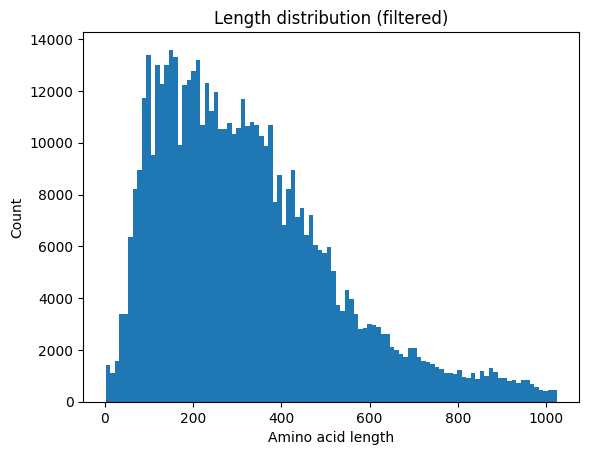

In [27]:
# Length distribution after filtering and capping
plt.figure()
plt.hist(final_fasta_df['length'], bins=100)
plt.title('Length distribution (filtered)')
plt.xlabel('Amino acid length')
plt.ylabel('Count')
plt.show()

In [32]:
path = '../data/uniprot_sprot.dat.gz'

data = []

with gzip.open(path, 'rt') as handle:
    for r in SwissProt.parse(handle):

        acc = r.accessions[0] if r.accessions else None
        keywords = r.keywords if r.keywords else None
        go_terms = [db_id for db, db_id, *rest in r.cross_references if db == "GO"]
        protein_families = []
        if r.comments:
            for comment in r.comments:
                if comment.startswith('SIMILARITY'):
                    protein_families.append(comment)
        
        data.append(
            {
                "id": acc,
                'keywords': keywords,
                "go_terms": go_terms,
                "protein_families": protein_families
            }
        )

df_dat = pd.DataFrame(data)

In [16]:
df_dat

,id,keywords,go_terms,protein_families
0,Q6GZX4,"[Activator, Reference proteome, Transcription,...",[GO:0046782],[]
1,Q6GZX3,"[Host membrane, Membrane, Reference proteome, ...",[GO:0033644],[]
2,Q197F8,[Reference proteome],[],[]
3,Q197F7,[Reference proteome],[],[]
4,Q6GZX2,"[Reference proteome, Signal]",[],[]
...,...,...,...,...
574622,Q6UY62,"[Host cell membrane, Host cytoplasm, Host memb...","[GO:0044220, GO:0020002, GO:0016020, GO:004442...",[SIMILARITY: Belongs to the arenaviridae Z pro...
574623,P08105,[Reference proteome],[],[]
574624,Q88470,"[Host cell membrane, Host cytoplasm, Host memb...","[GO:0044220, GO:0020002, GO:0016020, GO:004442...",[SIMILARITY: Belongs to the arenaviridae Z pro...
574625,A9JR22,"[Host cell membrane, Host cytoplasm, Host memb...","[GO:0044220, GO:0020002, GO:0016020, GO:004442...",[SIMILARITY: Belongs to the arenaviridae Z pro...


In [20]:
cols = ['go_terms', 'protein_families', 'id', 'keywords']

missing_counts = {}
for c in cols:
    missing_counts[c] = df_dat[c].isna().sum() + (df_dat[c].apply(lambda x: x == [] if isinstance(x, list) else False)).sum()

missing_counts

{'go_terms': np.int64(20645),
 'protein_families': np.int64(56082),
 'id': np.int64(0),
 'keywords': np.int64(6536)}

In [ ]:
df_merged = final_fasta_df.merge(df_dat, on='id', how='left')

In [22]:
df_merged

,id,entry_name,organism,taxonomy,gene_name,pe_level,sequence,length,description,keywords,go_terms,protein_families
0,Q6GZX4,001R_FRG3G,Frog virus 3 (isolate Goorha),654924,FV3-001R,4,MAFSAEDVLKEYDRRRRMEALLLSLYYPNDRKLLDYKEWSPPRVQV...,256,sp|Q6GZX4|001R_FRG3G Putative transcription fa...,"[Activator, Reference proteome, Transcription,...",[GO:0046782],[]
1,Q6GZX3,002L_FRG3G,Frog virus 3 (isolate Goorha),654924,FV3-002L,4,MSIIGATRLQNDKSDTYSAGPCYAGGCSAFTPRGTCGKDWDLGEQT...,320,sp|Q6GZX3|002L_FRG3G Uncharacterized protein 0...,"[Host membrane, Membrane, Reference proteome, ...",[GO:0033644],[]
2,Q197F8,002R_IIV3,Invertebrate iridescent virus 3,345201,IIV3-002R,4,MASNTVSAQGGSNRPVRDFSNIQDVAQFLLFDPIWNEQPGSIVPWK...,458,sp|Q197F8|002R_IIV3 Uncharacterized protein 00...,[Reference proteome],[],[]
3,Q197F7,003L_IIV3,Invertebrate iridescent virus 3,345201,IIV3-003L,4,MYQAINPCPQSWYGSPQLEREIVCKMSGAPHYPNYYPVHPNALGGA...,156,sp|Q197F7|003L_IIV3 Uncharacterized protein 00...,[Reference proteome],[],[]
4,Q6GZX2,003R_FRG3G,Frog virus 3 (isolate Goorha),654924,FV3-003R,3,MARPLLGKTSSVRRRLESLSACSIFFFLRKFCQKMASLVFLNSPVY...,438,sp|Q6GZX2|003R_FRG3G Uncharacterized protein 3...,"[Reference proteome, Signal]",[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...
547200,Q6UY62,Z_SABVB,Sabia mammarenavirus (isolate Human/Brasil/SPH...,3052299,Z,1,MGNSKSKSKLSANQYEQQTVNSTKQVAILKRQAEPSLYGRHNCRCC...,100,sp|Q6UY62|Z_SABVB RING finger protein Z OS=Sab...,"[Host cell membrane, Host cytoplasm, Host memb...","[GO:0044220, GO:0020002, GO:0016020, GO:004442...",[SIMILARITY: Belongs to the arenaviridae Z pro...
547201,P08105,Z_SHEEP,Ovis aries,9940,None,4,MSSSLEITSFYSFIWTPHIGPLLFGIGLWFSMFKEPSHFCPCQHPH...,79,sp|P08105|Z_SHEEP Putative uncharacterized pro...,[Reference proteome],[],[]
547202,Q88470,Z_TACVF,Tacaribe virus (strain Franze-Fernandez),928313,Z,1,MGNCNRTQKPSSSSNNLEKPPQAAEFRRTAEPSLYGRYNCKCCWFA...,95,sp|Q88470|Z_TACVF RING finger protein Z OS=Tac...,"[Host cell membrane, Host cytoplasm, Host memb...","[GO:0044220, GO:0020002, GO:0016020, GO:004442...",[SIMILARITY: Belongs to the arenaviridae Z pro...
547203,A9JR22,Z_TAMVU,Tamiami mammarenavirus (isolate Rat/United Sta...,3052329,Z,3,MGLRYSKEVRDRHGDKDPEGRIPITQTMPQTLYGRYNCKSCWFANK...,95,sp|A9JR22|Z_TAMVU RING finger protein Z OS=Tam...,"[Host cell membrane, Host cytoplasm, Host memb...","[GO:0044220, GO:0020002, GO:0016020, GO:004442...",[SIMILARITY: Belongs to the arenaviridae Z pro...


In [ ]:
output_path = '../data/swissprot_clean.parquet'
df_merged.to_csv(output_path)

In [6]:
size_mb = os.path.getsize(output_path) / (1024 ** 2)
print(f"Saved to: {output_path}")
print(f"File size: {size_mb:.2f} MB")

Saved to: ../data/swissprot_clean.csv
File size: 434.04 MB


In [7]:
path = '../data/swissprot_clean.csv'
df = pd.read_csv(path)

In [14]:
total_records = len(df)
min_length = df['length'].min()
mean_length = df['length'].mean()
median_length = df['length'].median()
p95_length = df['length'].quantile(0.95)
max_length = df['length'].max()

print(f"Total records: {total_records}")
print(f'Min length: {min_length}')
print(f"Mean length: {mean_length}")
print(f"Median length: {median_length}")
print(f"P95 length: {p95_length}")
print(f"Max length: {max_length}")

Total records: 547205
Min length: 2
Mean length: 324.38118620992134
Median length: 289.0
P95 length: 729.0
Max length: 1024


In [35]:
df["keywords"] = df["keywords"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df["go_terms"] = df["go_terms"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df["protein_families"] = df["protein_families"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

keyword_coverage = df["keywords"].apply(lambda x: len(x) > 0 if isinstance(x, list) else False).mean()
go_coverage = df["go_terms"].apply(lambda x: len(x) > 0 if isinstance(x, list) else False).mean()

print(f"Keyword coverage: {keyword_coverage * 100:.2f}%")
print(f"GO term coverage: {go_coverage * 100:.2f}%")

Keyword coverage: 98.84%
GO term coverage: 96.39%


## Summary

Total records: 547205

Min length: 2

Mean length: 324.38118620992134

Median length: 289.0

P95 length: 729.0

Max length: 1024


Number of fragments removed: 9266

Sequences over 1024 aa removed: 18156

Keyword coverage: 98.84%

GO term coverage: 96.39%